# Step 3 — Feature Data Quality Check

Review the engineered daily feature matrix before training models.

**Contents**
1. Overview & split sizes
2. Target distribution
3. Missing values
4. Feature groups
5. NLP point-in-time spot-check
6. NLP signal per quarter window
7. News features sanity check
8. Constant / near-constant columns
9. Sample rows around key events

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4f}'.format)

PATH = '../data/processed/features/model_features_daily.parquet'
df = pd.read_parquet(PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

TARGET = 'td_return_5d_fwd'
CUTOFF_A = pd.Timestamp('2024-12-31')
CUTOFF_C = pd.Timestamp('2024-08-22')
feature_cols = [c for c in df.columns if c not in {TARGET, 'date'}]

CALL_DATES = {
    'FY2021Q1':'2021-02-25','FY2021Q2':'2021-05-27','FY2021Q3':'2021-08-26','FY2021Q4':'2021-12-02',
    'FY2022Q1':'2022-03-03','FY2022Q2':'2022-05-26','FY2022Q3':'2022-08-25','FY2022Q4':'2022-12-01',
    'FY2023Q1':'2023-03-02','FY2023Q2':'2023-05-26','FY2023Q3':'2023-08-24','FY2023Q4':'2023-11-30',
    'FY2024Q1':'2024-02-29','FY2024Q2':'2024-05-23','FY2024Q3':'2024-08-22','FY2024Q4':'2024-12-05',
    'FY2025Q1':'2025-02-27','FY2025Q2':'2025-05-22','FY2025Q3':'2025-08-28','FY2025Q4':'2025-12-04',
    'FY2026Q1':'2026-04-03',
}

print('Loaded:', df.shape)

Loaded: (1285, 139)


## 1. Overview & Split Sizes

In [2]:
train_a = df[df['date'] <= CUTOFF_A]
test_a  = df[df['date'] >  CUTOFF_A]
train_c = df[df['date'] <= CUTOFF_C]
test_c  = df[df['date'] >  CUTOFF_C]

overview = pd.DataFrame({
    'Split': ['Option A — Train', 'Option A — Test', 'Option C — Train', 'Option C — Test'],
    'Rows': [len(train_a), len(test_a), len(train_c), len(test_c)],
    'Start': [train_a['date'].min().date(), test_a['date'].min().date(),
               train_c['date'].min().date(), test_c['date'].min().date()],
    'End':   [train_a['date'].max().date(), test_a['date'].max().date(),
               train_c['date'].max().date(), test_c['date'].max().date()],
    'Crisis / consent order in set?': [
        'Barely (Dec 5–31 only)', 'No — recovery only',
        'No', 'Yes — full crisis + recovery'
    ]
})
print(f'Total rows: {len(df):,}   |   Features: {len(feature_cols)}   |   Target: {TARGET}')
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}\n')
display(overview)

Total rows: 1,285   |   Features: 137   |   Target: td_return_5d_fwd
Date range: 2021-02-25 → 2026-04-09



,Split,Rows,Start,End,Crisis / consent order in set?
0,Option A — Train,966,2021-02-25,2024-12-31,Barely (Dec 5–31 only)
1,Option A — Test,319,2025-01-02,2026-04-09,No — recovery only
2,Option C — Train,877,2021-02-25,2024-08-22,No
3,Option C — Test,408,2024-08-23,2026-04-09,Yes — full crisis + recovery


## 2. Target Distribution

,Metric,Value
0,Mean,0.35%
1,Std,2.46%
2,Min,-9.58%
3,Max,7.24%
4,% Positive,59.7%
5,% Negative,40.0%


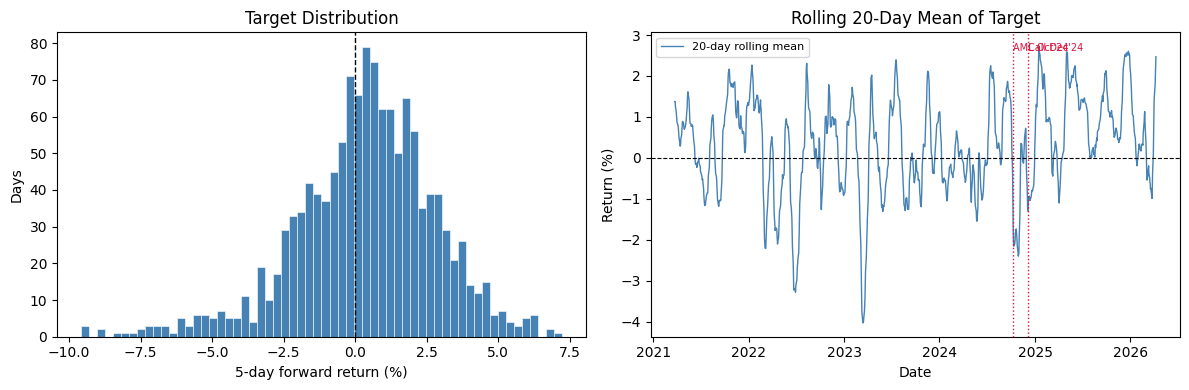

In [3]:
tgt = df[TARGET]
stats = pd.DataFrame({
    'Metric': ['Mean', 'Std', 'Min', 'Max', '% Positive', '% Negative'],
    'Value':  [f'{tgt.mean()*100:.2f}%', f'{tgt.std()*100:.2f}%',
               f'{tgt.min()*100:.2f}%', f'{tgt.max()*100:.2f}%',
               f'{(tgt>0).mean()*100:.1f}%', f'{(tgt<0).mean()*100:.1f}%']
})
display(stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(tgt * 100, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_xlabel('5-day forward return (%)')
axes[0].set_ylabel('Days')
axes[0].set_title('Target Distribution')

axes[1].plot(df['date'], tgt.rolling(20).mean() * 100, color='steelblue', linewidth=1, label='20-day rolling mean')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
for label, dt in [('AML Oct\'24', '2024-10-10'), ('Call Dec\'24', '2024-12-05')]:
    axes[1].axvline(pd.Timestamp(dt), color='crimson', linewidth=1, linestyle=':')
    axes[1].text(pd.Timestamp(dt), axes[1].get_ylim()[1]*0.85, label, fontsize=7, color='crimson', ha='left')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Return (%)')
axes[1].set_title('Rolling 20-Day Mean of Target')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 3. Missing Values

In [4]:
missing = df[feature_cols].isnull().sum()
total_cells = len(df) * len(feature_cols)
print(f'Total missing cells: {missing.sum():,} / {total_cells:,}  ({missing.sum()/total_cells*100:.2f}%)')
print(f'Columns with any missing: {(missing > 0).sum()} / {len(feature_cols)}\n')

miss_df = pd.DataFrame({
    'Column': missing[missing > 0].index,
    'Missing count': missing[missing > 0].values,
    'Missing %': (missing[missing > 0].values / len(df) * 100).round(1),
    'Root cause': [
        'No 12m-ago CPI (first year)' if 'cpi_yoy' in c
        else 'No prior quarter (FY2021Q1 window)' if ('_delta' in c or '_surprise' in c)
        else 'No news in 7-day window'
        for c in missing[missing > 0].index
    ]
}).sort_values('Missing count', ascending=False).reset_index(drop=True)

print('All expected — handled by median imputation at model training time.')
display(miss_df)

Total missing cells: 0 / 176,045  (0.00%)
Columns with any missing: 0 / 137

All expected — handled by median imputation at model training time.


,Column,Missing count,Missing %,Root cause


## 4. Feature Groups

In [5]:
price_cols = [c for c in feature_cols if c.startswith(('td_','xfn_','tsx_'))]
fx_cols    = [c for c in feature_cols if c.startswith('fx_')]
rate_cols  = [c for c in feature_cols if c.startswith(('rate_','yield_'))]
cpi_cols   = [c for c in feature_cols if c.startswith('cpi_')]
news_cols  = [c for c in feature_cols if c.startswith('news_') or 'last_news' in c]
event_cols = [c for c in feature_cols if c.startswith('is_')]
nlp_cols   = [c for c in feature_cols if c not in set(price_cols+fx_cols+rate_cols+cpi_cols+news_cols+event_cols)]

groups = [
    ('Price / momentum (TD, XFN, GSPTSE)', price_cols),
    ('FX (USD/CAD)', fx_cols),
    ('Interest rates & yields', rate_cols),
    ('CPI', cpi_cols),
    ('News rolling windows', news_cols),
    ('Event flags', event_cols),
    ('NLP engineered (level / delta / surprise)', nlp_cols),
]

group_df = pd.DataFrame([
    {'Group': name, 'Count': len(cols), 'Columns (first 5)': ', '.join(cols[:5]) + ('...' if len(cols)>5 else '')}
    for name, cols in groups
])
display(group_df)

,Group,Count,Columns (first 5)
0,"Price / momentum (TD, XFN, GSPTSE)",18,"td_return_1d, td_return_5d, td_return_20d, xfn..."
1,FX (USD/CAD),3,"fx_usdcad_level, fx_usdcad_return_5d, fx_usdca..."
2,Interest rates & yields,7,"rate_overnight_level, rate_overnight_change_5d..."
3,CPI,2,"cpi_level, cpi_yoy_change"
4,News rolling windows,8,"news_sentiment_mean_ffill, news_sentiment_mean..."
5,Event flags,2,"is_earnings_week, is_news_burst"
6,NLP engineered (level / delta / surprise),97,"transcript_ceo_prep_sentiment_mean_ffill, tran..."


## 5. NLP Point-in-Time Spot-Check

Verify that CEO prep sentiment updates exactly on the call date, not before.

In [6]:
ceo_col = 'transcript_ceo_prep_sentiment_mean_ffill'
rows = []
for fq, dt in sorted(CALL_DATES.items(), key=lambda x: x[1]):
    call_ts = pd.Timestamp(dt)
    before  = df[df['date'] < call_ts].tail(1)
    on      = df[df['date'] == call_ts]
    after   = df[df['date'] > call_ts].head(1)
    def v(frame):
        if len(frame) == 0 or pd.isna(frame[ceo_col].iloc[0]): return 'n/a'
        return f'{frame[ceo_col].iloc[0]:.3f}'
    rows.append({'Quarter': fq, 'Call date': dt,
                 'Day before': v(before), 'On call date': v(on), 'Day after': v(after)})

pit = pd.DataFrame(rows)

# Highlight rows where value changes (activation works correctly)
def highlight_change(row):
    changed = row['Day before'] != row['On call date'] and row['Day before'] != 'n/a'
    return ['background-color: #d4edda' if changed else '' for _ in row]

display(pit.style.apply(highlight_change, axis=1))

,Quarter,Call date,Day before,On call date,Day after
0,FY2021Q1,2021-02-25,n/a,0.767,0.767
1,FY2021Q2,2021-05-27,0.767,0.800,0.800
2,FY2021Q3,2021-08-26,0.800,0.800,0.800
3,FY2021Q4,2021-12-02,0.800,0.775,0.775
4,FY2022Q1,2022-03-03,0.775,0.800,0.800
5,FY2022Q2,2022-05-26,0.800,0.767,0.767
6,FY2022Q3,2022-08-25,0.767,0.800,0.800
7,FY2022Q4,2022-12-01,0.800,0.775,0.775
8,FY2023Q1,2023-03-02,0.775,0.767,0.767
9,FY2023Q2,2023-05-26,0.767,0.750,0.750


## 6. NLP Signal per Quarter Window

Mean of key features within each inter-call window, confirming escalation and recovery patterns.

In [7]:
call_tss = sorted([pd.Timestamp(v) for v in CALL_DATES.values()])
fq_labels = {pd.Timestamp(v): k for k, v in CALL_DATES.items()}

records = []
for i, start in enumerate(call_tss):
    end = call_tss[i+1] - pd.Timedelta(days=1) if i+1 < len(call_tss) else df['date'].max()
    w = df[(df['date'] >= start) & (df['date'] <= end)]
    if len(w) == 0: continue
    records.append({
        'Quarter': fq_labels.get(start, '?'),
        'CEO prep': w['transcript_ceo_prep_sentiment_mean_ffill'].mean(),
        'CFO prep': w['transcript_cfo_prep_sentiment_mean_ffill'].mean(),
        'AML share': w['topic_regulatory_AML_share_ffill'].mean(),
        'AML sent': w['topic_regulatory_AML_sentiment_ffill'].mean(),
        'Guidance share': w['topic_guidance_share_ffill'].mean(),
        'Framing gap': w['framing_gap_ffill'].mean(),
        'TD 5d fwd ret %': w[TARGET].mean() * 100,
    })

qdf = pd.DataFrame(records)

# Color AML share col: redder = higher
def color_aml(val):
    norm = (val - qdf['AML share'].min()) / (qdf['AML share'].max() - qdf['AML share'].min() + 1e-9)
    r = int(255 * norm); g = int(255 * (1 - norm * 0.5)); b = int(255 * (1 - norm))
    return f'background-color: rgb({r},{g},{b}); color: black'

def color_ceo(val):
    norm = (val - qdf['CEO prep'].min()) / (qdf['CEO prep'].max() - qdf['CEO prep'].min() + 1e-9)
    g = int(200 * norm); r = int(255 * (1 - norm * 0.6))
    return f'background-color: rgb({r},{g},120); color: black'

display(
    qdf.style
    .format({'CEO prep':'{:.3f}','CFO prep':'{:.3f}','AML share':'{:.3f}',
             'AML sent':'{:.3f}','Guidance share':'{:.3f}','Framing gap':'{:.3f}',
             'TD 5d fwd ret %':'{:+.1f}%'})
    .map(color_aml, subset=['AML share'])
    .map(color_ceo, subset=['CEO prep'])
)

,Quarter,CEO prep,CFO prep,AML share,AML sent,Guidance share,Framing gap,TD 5d fwd ret %
0,FY2021Q1,0.767,0.700,0.189,0.260,0.075,0.540,+1.0%
1,FY2021Q2,0.800,0.700,0.110,0.275,0.144,0.513,-0.3%
2,FY2021Q3,0.800,0.700,0.147,0.291,0.093,0.548,+1.1%
3,FY2021Q4,0.775,0.700,0.179,0.251,0.098,0.555,+0.3%
4,FY2022Q1,0.800,0.350,0.111,0.239,0.117,0.547,-0.0%
5,FY2022Q2,0.767,0.200,0.101,0.206,0.095,0.543,-0.8%
6,FY2022Q3,0.800,0.000,0.115,0.128,0.083,0.569,+0.5%
7,FY2022Q4,0.775,0.350,0.193,0.181,0.067,0.555,-0.2%
8,FY2023Q1,0.767,0.000,0.145,0.104,0.126,0.657,-0.9%
9,FY2023Q2,0.750,0.000,0.115,0.124,0.115,0.569,+0.5%


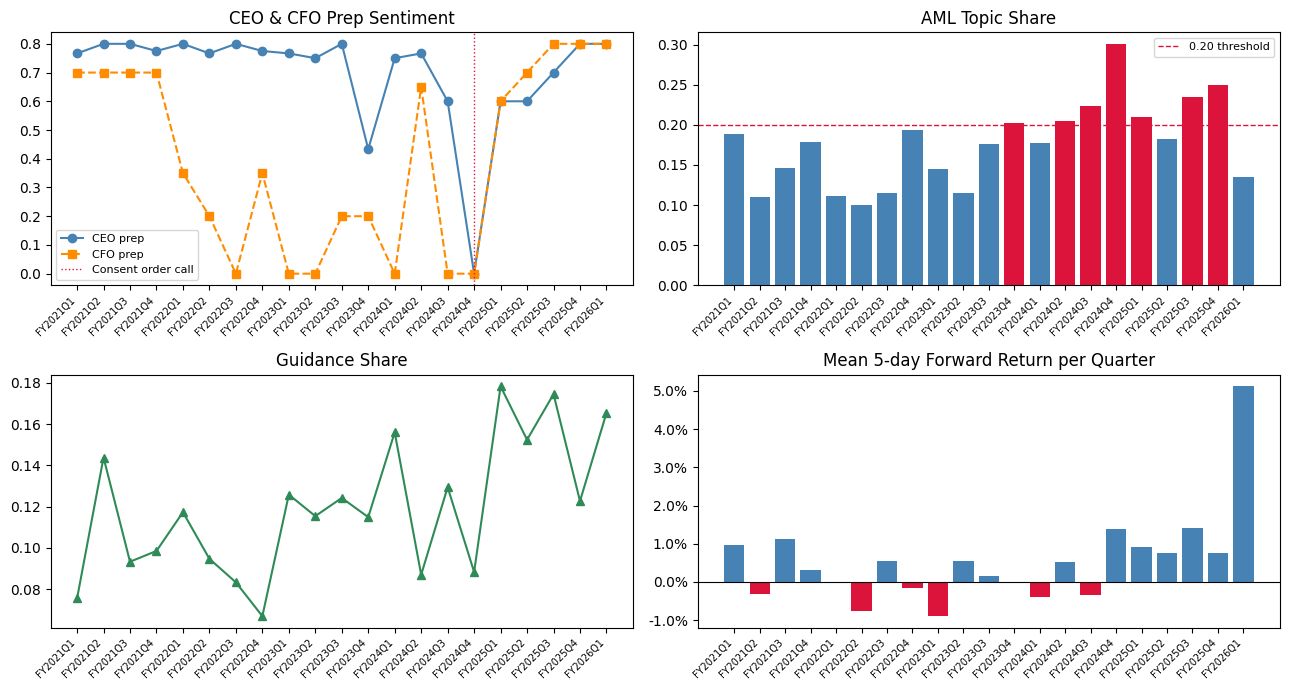

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
quarters = qdf['Quarter'].tolist()
x = range(len(quarters))

ax = axes[0, 0]
ax.plot(x, qdf['CEO prep'], marker='o', color='steelblue', label='CEO prep')
ax.plot(x, qdf['CFO prep'], marker='s', color='darkorange', linestyle='--', label='CFO prep')
ax.axvline(quarters.index('FY2024Q4'), color='crimson', linewidth=1, linestyle=':', label='Consent order call')
ax.set_xticks(x); ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=7)
ax.set_title('CEO & CFO Prep Sentiment'); ax.legend(fontsize=8)

ax = axes[0, 1]
ax.bar(x, qdf['AML share'], color=['crimson' if v > 0.2 else 'steelblue' for v in qdf['AML share']])
ax.axhline(0.2, color='crimson', linewidth=1, linestyle='--', label='0.20 threshold')
ax.set_xticks(x); ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=7)
ax.set_title('AML Topic Share'); ax.legend(fontsize=8)

ax = axes[1, 0]
ax.plot(x, qdf['Guidance share'], marker='^', color='seagreen')
ax.set_xticks(x); ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=7)
ax.set_title('Guidance Share')

ax = axes[1, 1]
colors = ['crimson' if v < 0 else 'steelblue' for v in qdf['TD 5d fwd ret %']]
ax.bar(x, qdf['TD 5d fwd ret %'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(quarters, rotation=45, ha='right', fontsize=7)
ax.set_title('Mean 5-day Forward Return per Quarter')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f'{y:.1f}%'))

plt.tight_layout()
plt.show()

## 7. News Features Sanity Check

,Feature,Mean,Std,Min,Max,Coverage %
0,news_sentiment_mean_ffill,0.542,0.077,0.405,0.676,100.0%
1,news_sentiment_mean_delta,-490.226,2159.873,-9999.000,0.167,100.0%
2,news_sentiment_mean_surprise,-490.238,2159.870,-9999.000,0.122,100.0%
3,news_sent_mean_7d,0.589,0.239,-0.600,0.900,100.0%
4,news_sent_mean_30d,0.581,0.123,0.206,0.800,100.0%
5,news_count_7d,4.540,4.978,0.000,27.000,100.0%
6,news_count_30d,16.662,8.331,4.000,40.000,100.0%
7,days_since_last_news,2.158,2.799,0.000,16.000,100.0%



Top 5 dates by 7-day news volume:


,date,news_count_7d,news_sent_mean_7d,td_return_5d_fwd
0,2024-12-05,27,0.1370,2.8%
1,2024-12-06,27,0.1370,3.21%
2,2024-12-10,27,0.1630,-0.09%
3,2024-12-09,26,0.1423,1.42%
4,2024-12-11,26,0.1077,-1.27%


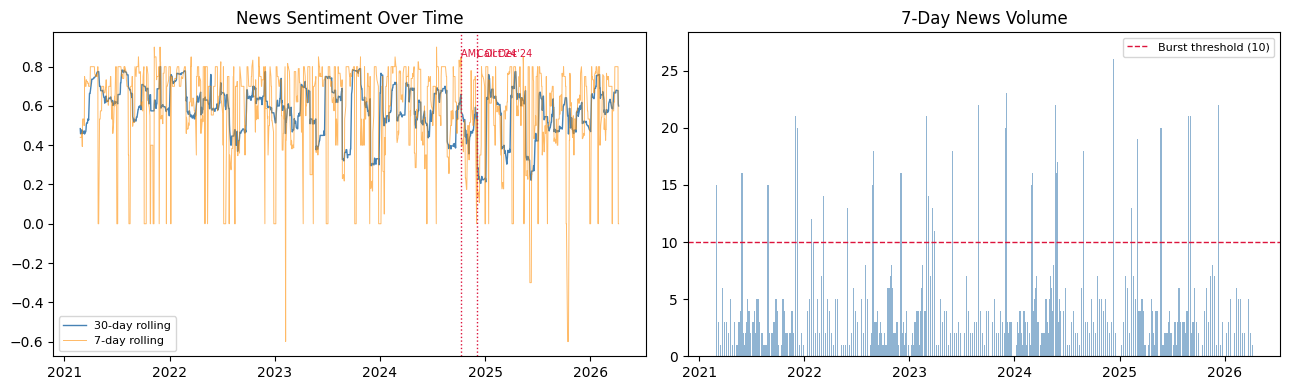

In [9]:
news_stats = pd.DataFrame([
    {'Feature': col,
     'Mean': df[col].mean(), 'Std': df[col].std(),
     'Min': df[col].min(), 'Max': df[col].max(),
     'Coverage %': df[col].notna().mean() * 100}
    for col in news_cols
])
display(news_stats.style.format({'Mean':'{:.3f}','Std':'{:.3f}','Min':'{:.3f}','Max':'{:.3f}','Coverage %':'{:.1f}%'}))

print('\nTop 5 dates by 7-day news volume:')
display(df.nlargest(5, 'news_count_7d')[['date','news_count_7d','news_sent_mean_7d', TARGET]]
          .assign(**{TARGET: lambda x: (x[TARGET]*100).round(2).astype(str)+'%'})
          .reset_index(drop=True))

# Plot news sentiment vs target
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(df['date'], df['news_sent_mean_30d'], color='steelblue', linewidth=1, label='30-day rolling')
ax.plot(df['date'], df['news_sent_mean_7d'], color='darkorange', linewidth=0.7, alpha=0.6, label='7-day rolling')
for dt, lbl in [('2024-10-10','AML Oct\'24'),('2024-12-05','Call Dec\'24')]:
    ax.axvline(pd.Timestamp(dt), color='crimson', linewidth=1, linestyle=':')
    ax.text(pd.Timestamp(dt), 0.85, lbl, fontsize=7, color='crimson')
ax.set_title('News Sentiment Over Time'); ax.legend(fontsize=8)

ax = axes[1]
ax.bar(df['date'], df['news_count_7d'], width=1, color='steelblue', alpha=0.6)
ax.axhline(10, color='crimson', linewidth=1, linestyle='--', label='Burst threshold (10)')
ax.set_title('7-Day News Volume'); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 8. Constant / Near-Constant Columns

In [10]:
std_vals = df[feature_cols].std()
constant = std_vals[std_vals == 0].index.tolist()
near_const = std_vals[(std_vals > 0) & (std_vals < 1e-6)].index.tolist()
print(f'Fully constant columns:       {len(constant)}')
print(f'Near-constant (sigma < 1e-6): {len(near_const)}')
if not constant and not near_const:
    print('No constant or near-constant columns found. All features have meaningful variance.')

Fully constant columns:       0
Near-constant (sigma < 1e-6): 0
No constant or near-constant columns found. All features have meaningful variance.


## 9. Sample Rows Around Key Events

In [11]:
show_cols = [
    'date', TARGET, 'td_return_5d', 'td_vs_xfn_5d',
    'transcript_ceo_prep_sentiment_mean_ffill',
    'transcript_ceo_prep_sentiment_mean_delta',
    'topic_regulatory_AML_share_ffill',
    'topic_guidance_share_ffill',
    'news_sent_mean_7d',
    'news_count_7d',
    'days_since_call',
]
show_cols = [c for c in show_cols if c in df.columns]

key_events = [
    ('AML consent order',         '2024-10-10'),
    ('FY2024Q4 earnings call',    '2024-12-05'),
    ('FY2025Q1 earnings call',    '2025-02-27'),
    ('FY2026Q1 earnings call',    '2026-04-03'),
]

for label, dt in key_events:
    ts = pd.Timestamp(dt)
    # Show 2 days before, the event day, 2 days after
    window = df[(df['date'] >= ts - pd.Timedelta(days=3)) &
                (df['date'] <= ts + pd.Timedelta(days=3))][show_cols].copy()
    window[TARGET] = (window[TARGET] * 100).round(2).astype(str) + '%'
    window['td_return_5d'] = (window['td_return_5d'] * 100).round(2).astype(str) + '%'
    window['td_vs_xfn_5d'] = (window['td_vs_xfn_5d'] * 100).round(2).astype(str) + '%'
    print(f'\n--- {label} ({dt}) ---')
    display(window.reset_index(drop=True))


--- AML consent order (2024-10-10) ---


,date,td_return_5d_fwd,td_return_5d,td_vs_xfn_5d,transcript_ceo_prep_sentiment_mean_ffill,transcript_ceo_prep_sentiment_mean_delta,topic_regulatory_AML_share_ffill,topic_guidance_share_ffill,news_sent_mean_7d,news_count_7d,days_since_call
0,2024-10-07,-9.58%,1.65%,1.79%,0.6000,-0.1667,0.2235,0.1294,0.8000,2,46.0000
1,2024-10-08,-9.49%,0.8%,0.75%,0.6000,-0.1667,0.2235,0.1294,0.8000,2,47.0000
2,2024-10-09,-9.56%,2.21%,1.6%,0.6000,-0.1667,0.2235,0.1294,0.8500,2,48.0000
3,2024-10-10,-4.79%,-3.57%,-4.19%,0.6000,-0.1667,0.2235,0.1294,0.4000,4,49.0000
4,2024-10-11,-0.05%,-8.21%,-8.75%,0.6000,-0.1667,0.2235,0.1294,0.4000,4,50.0000



--- FY2024Q4 earnings call (2024-12-05) ---


,date,td_return_5d_fwd,td_return_5d,td_vs_xfn_5d,transcript_ceo_prep_sentiment_mean_ffill,transcript_ceo_prep_sentiment_mean_delta,topic_regulatory_AML_share_ffill,topic_guidance_share_ffill,news_sent_mean_7d,news_count_7d,days_since_call
0,2024-12-02,-5.51%,1.49%,0.28%,0.6000,-0.1667,0.2235,0.1294,0.0000,1,102.0000
1,2024-12-03,-4.94%,0.71%,0.37%,0.6000,-0.1667,0.2235,0.1294,0.5333,3,103.0000
2,2024-12-04,-4.9%,0.73%,0.7%,0.6000,-0.1667,0.2235,0.1294,0.5333,3,104.0000
3,2024-12-05,2.8%,-6.76%,-7.11%,0.0000,-0.6000,0.3004,0.0883,0.1370,27,0.0000
4,2024-12-06,3.21%,-7.22%,-7.73%,0.0000,-0.6000,0.3004,0.0883,0.1370,27,1.0000



--- FY2025Q1 earnings call (2025-02-27) ---


,date,td_return_5d_fwd,td_return_5d,td_vs_xfn_5d,transcript_ceo_prep_sentiment_mean_ffill,transcript_ceo_prep_sentiment_mean_delta,topic_regulatory_AML_share_ffill,topic_guidance_share_ffill,news_sent_mean_7d,news_count_7d,days_since_call
0,2025-02-24,2.09%,0.0%,0.63%,0.0000,-0.6000,0.3004,0.0883,0.3500,4,81.0000
1,2025-02-25,-0.41%,0.16%,0.8%,0.0000,-0.6000,0.3004,0.0883,0.4400,5,82.0000
2,2025-02-26,-0.79%,0.13%,0.22%,0.0000,-0.6000,0.3004,0.0883,0.5500,4,83.0000
3,2025-02-27,-1.8%,0.81%,1.35%,0.6000,0.6000,0.2102,0.1783,0.2053,19,0.0000
4,2025-02-28,-1.22%,1.79%,0.19%,0.6000,0.6000,0.2102,0.1783,0.1778,18,1.0000



--- FY2026Q1 earnings call (2026-04-03) ---


,date,td_return_5d_fwd,td_return_5d,td_vs_xfn_5d,transcript_ceo_prep_sentiment_mean_ffill,transcript_ceo_prep_sentiment_mean_delta,topic_regulatory_AML_share_ffill,topic_guidance_share_ffill,news_sent_mean_7d,news_count_7d,days_since_call
0,2026-03-31,5.64%,0.95%,-0.15%,0.8000,0.1000,0.2491,0.1227,0.8000,3,117.0000
1,2026-04-01,5.88%,0.76%,-0.17%,0.8000,0.1000,0.2491,0.1227,0.8000,2,118.0000
2,2026-04-02,5.94%,2.99%,0.3%,0.8000,0.1000,0.2491,0.1227,0.8000,2,119.0000
3,2026-04-06,6.25%,5.18%,0.88%,0.8000,0.0000,0.1353,0.1654,0.8000,2,3.0000
